# France thesis pilot: reproducible analysis

This notebook rebuilds the final French analytical dataset, runs all descriptive, inferential and predictive models, and displays the principal outputs. The authoritative written interpretation is in `reports/france/france_pilot_report.md`.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((p for p in roots if (p / 'build_france_analysis.py').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Open this notebook from inside the project directory.')
%cd $PROJECT_ROOT
print(f'Project root: {PROJECT_ROOT}')

/Users/ioannabousmpouki/Desktop/reposkills/green-ai-skills/green-ai-skills
Project root: /Users/ioannabousmpouki/Desktop/reposkills/green-ai-skills/green-ai-skills


## 1. Rebuild the analytical dataset

In [2]:
%run build_france_analysis.py

Input rows: 120,429
Analytical rows: 101,944
Skill mix:
skill_mix
neither               67611
soft_only             33204
technical_only          658
technical_and_soft      471
Output: files/cleaned/fr_analysis.csv
Validation sample: files/cleaned/fr_validation_sample.csv (300 rows)


## 2. Run descriptive analysis, regressions and robustness checks

In [3]:
%run analyze_france.py

Quality summary
 analysis_rows  trimmed_rows  salary_p01  salary_median  salary_p99  technical_rows  strict_technical_rows  soft_rows  missing_education_rows
        101940        100209     21000.0        30000.0    130000.0            1129                   1129      33675                  101940

Salary by skill mix
                    count     mean   median      std      q25      q75
skill_mix                                                             
neither             67607  36501.2  29998.5  24237.8  25195.5  36500.0
soft_only           33204  38471.3  33000.0  20727.2  27500.0  42000.0
technical_and_soft    471  47824.4  45000.0  16929.1  37500.0  55000.0
technical_only        658  44958.6  43000.0  16736.5  36000.0  50000.0

Regression coefficients
                    model                                                                     term  coefficient  std_error  p_value  ci_low  ci_high  percent_association  percent_ci_low  percent_ci_high
          unadjusted_full

## 3. Core descriptive results

,skill_mix,count,mean,median,std,q25,q75
0,neither,67607,36501.2,29998.5,24237.8,25195.5,36500.0
1,soft_only,33204,38471.3,33000.0,20727.2,27500.0,42000.0
2,technical_and_soft,471,47824.4,45000.0,16929.1,37500.0,55000.0
3,technical_only,658,44958.6,43000.0,16736.5,36000.0,50000.0


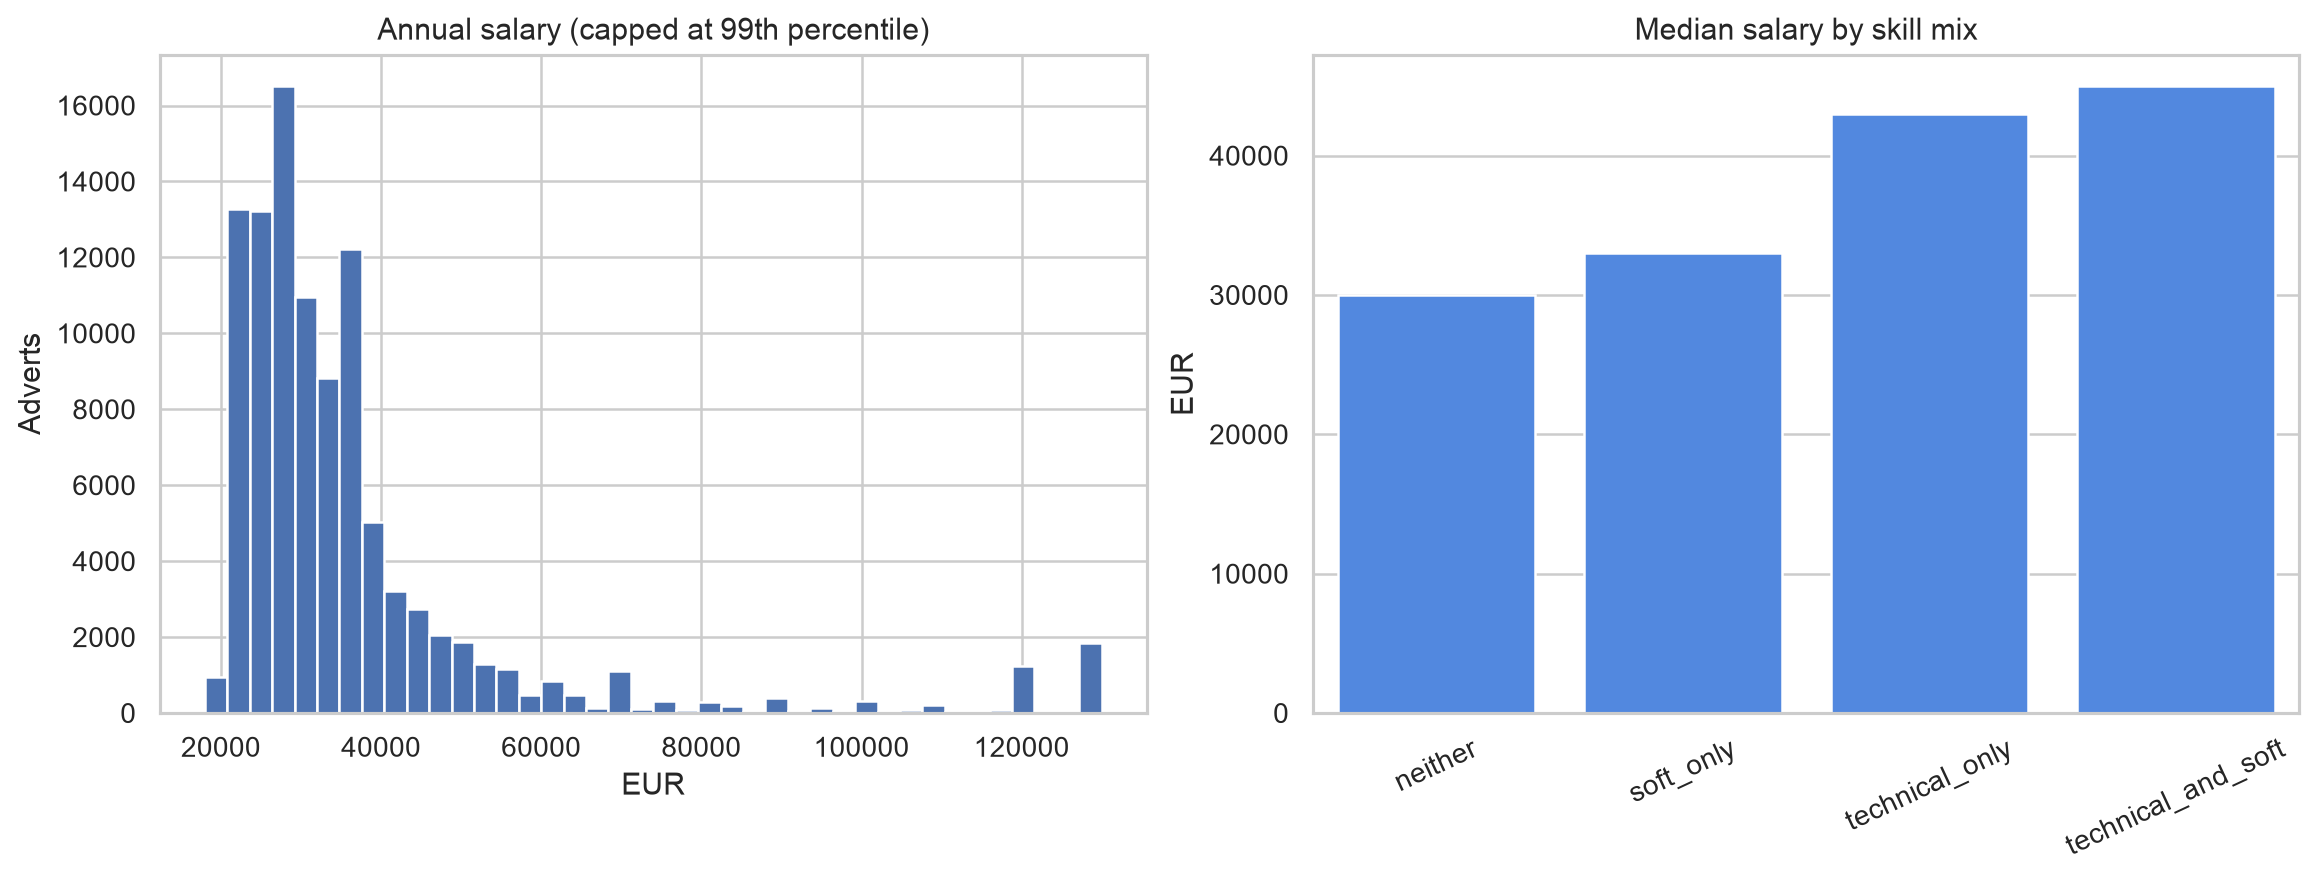

In [4]:
salary_mix = pd.read_csv('reports/france/salary_by_skill_mix.csv')
display(salary_mix.round(1))
display(Image(filename='reports/france/salary_overview.png'))

## 4. Adjusted regression results

,term,percent_association,percent_ci_low,percent_ci_high,p_value
6,"C(skill_mix, Treatment(reference='neither'))[T...",3.436,1.693,5.209,0.0
7,"C(skill_mix, Treatment(reference='neither'))[T...",30.552,16.056,46.859,0.0
8,"C(skill_mix, Treatment(reference='neither'))[T...",27.859,17.537,39.088,0.0


,term,percent_association,percent_ci_low,percent_ci_high,p_value
12,has_ai_ml,29.175,18.018,41.386,0.000
13,has_data_analysis,9.138,3.368,15.230,0.002
14,has_data_engineering,16.608,13.334,19.977,0.000
15,has_software,21.683,16.406,27.200,0.000
16,has_cloud_devops,18.292,13.932,22.819,0.000
17,has_cybersecurity,26.242,13.879,39.946,0.000
18,has_networks_systems,4.007,-1.580,9.912,0.162
19,has_soft_communication,2.187,0.789,3.604,0.002
20,has_soft_teamwork,3.923,1.422,6.486,0.002
21,has_soft_adaptability,1.087,-0.458,2.655,0.168


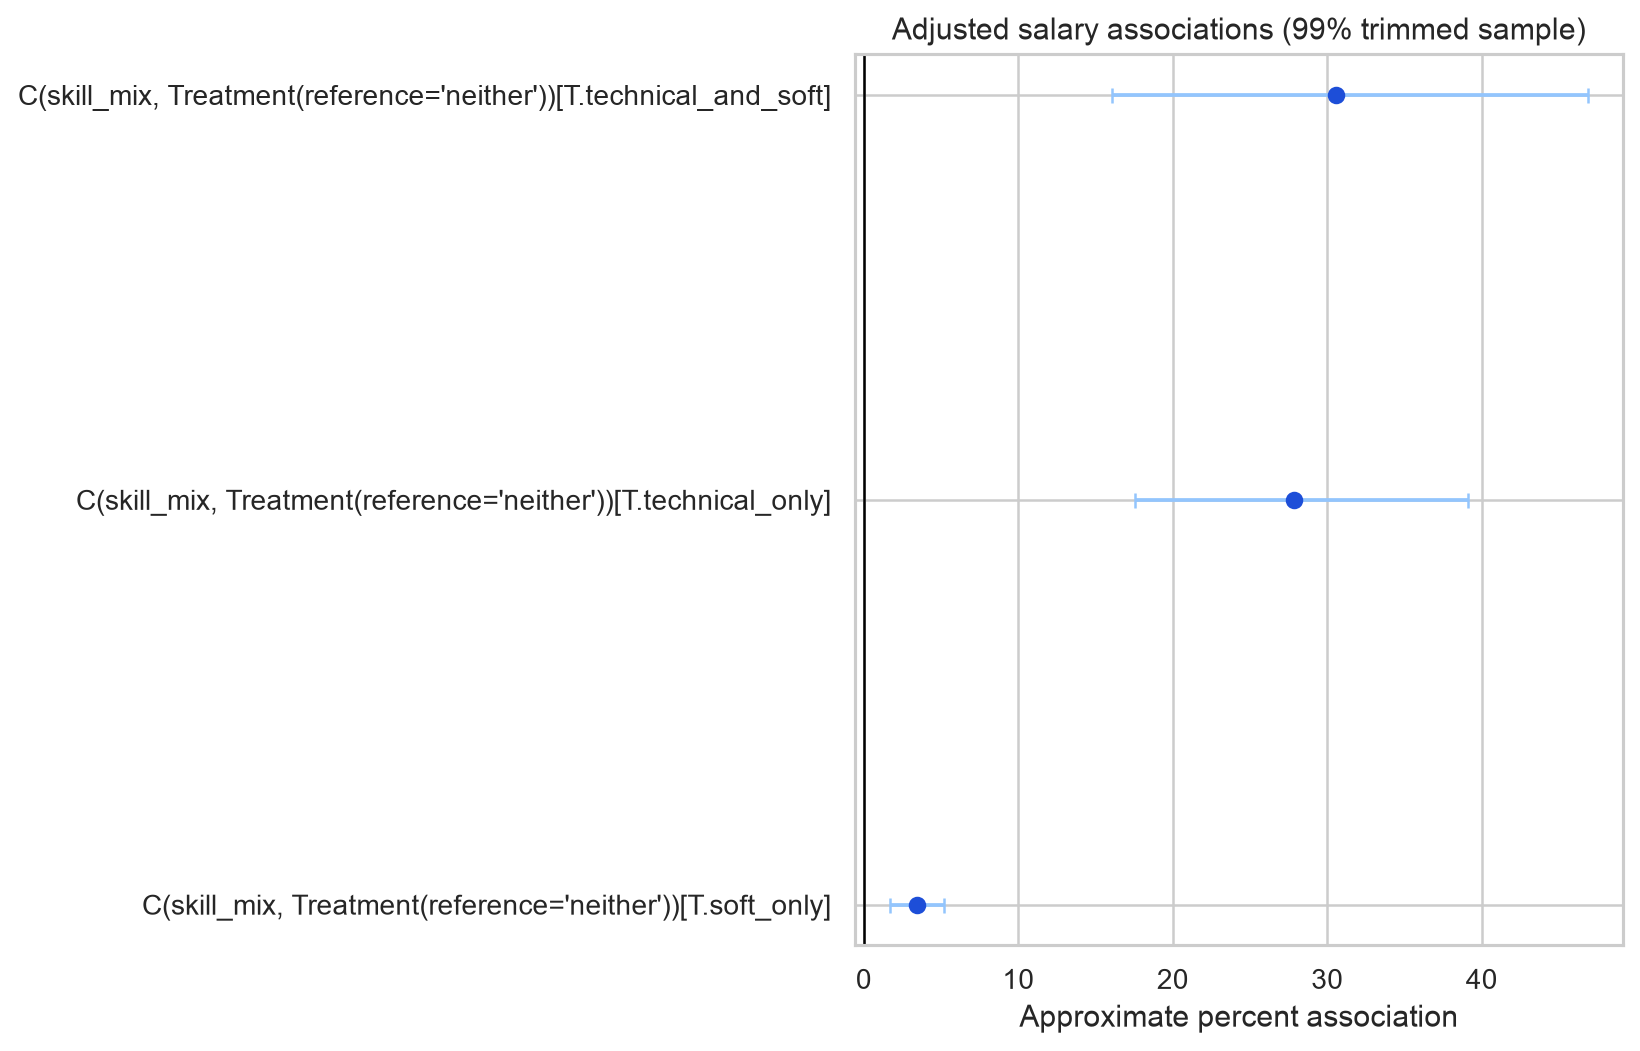

In [5]:
coefs = pd.read_csv('reports/france/regression_coefficients.csv')
main_mix = coefs[coefs['model'].eq('adjusted_trimmed')]
categories = coefs[coefs['model'].eq('category_adjusted_trimmed')]
display(main_mix[['term', 'percent_association', 'percent_ci_low', 'percent_ci_high', 'p_value']].round(3))
display(categories[['term', 'percent_association', 'percent_ci_low', 'percent_ci_high', 'p_value']].round(3))
display(Image(filename='reports/france/adjusted_coefficients.png'))

## 5. Direct technical + soft comparison

In [6]:
contrast = pd.read_csv('reports/france/skill_mix_contrast.csv')
display(contrast.round(3))

,contrast,coefficient_difference,std_error,p_value,percent_difference,percent_ci_low,percent_ci_high
0,technical_and_soft minus technical_only,0.021,0.021,0.327,2.106,-2.06,6.45


## 6. Predictive performance: random and temporal hold-outs

In [7]:
metrics = pd.read_csv('reports/france/prediction_metrics.csv')
display(metrics.round(3))

,split,model,train_n,test_n,mae_eur,rmse_eur,r2
0,random_80_20,median_baseline,80167,20042,10410.782,20044.106,-0.110
1,random_80_20,skills_only_ridge,80167,20042,10469.809,19104.027,-0.008
2,random_80_20,controls_only_ridge,80167,20042,6035.074,10432.013,0.699
3,random_80_20,skills_and_controls_ridge,80167,20042,5956.351,10340.531,0.705
4,temporal_80_20,median_baseline,80167,20042,8044.365,14218.061,-0.011
5,temporal_80_20,skills_only_ridge,80167,20042,8751.426,14086.620,0.008
6,temporal_80_20,controls_only_ridge,80167,20042,5028.613,8290.141,0.656
7,temporal_80_20,skills_and_controls_ridge,80167,20042,4967.458,8213.088,0.663


## 7. Main interpretation

- Technical skills are positively associated with offered salaries after controls.
- AI/ML, cybersecurity, software and cloud/DevOps have the largest point estimates.
- Networks/systems, adaptability, initiative/responsibility and customer interaction are not statistically distinguishable from zero at the 5% level.
- Technical + soft has a higher point estimate than technical-only, but their direct difference is not significant (p = 0.327).
- Skills alone have almost no out-of-sample predictive power; occupation and job characteristics explain most of the predictable salary variation.

**These are conditional associations, not causal effects.**

## 8. Full report

In [8]:
report = Path('reports/france/france_pilot_report.md').read_text(encoding='utf-8')
display(Markdown(report))

# Γαλλία: δεξιότητες και προσφερόμενοι μισθοί

## Αναλυτικό report του πιλοτικού σταδίου

## 1. Σκοπός

Το γαλλικό pilot εξετάζει εάν η παρουσία τεχνικών, AI/data και κοινωνικών δεξιοτήτων στις αγγελίες εργασίας συνδέεται με διαφοροποίηση του προσφερόμενου μισθού. Η ανάλυση σχεδιάστηκε ως πρότυπο για τη μετέπειτα εφαρμογή της ίδιας μεθοδολογίας στις υπόλοιπες χώρες.

Η μελέτη απαντά σε τέσσερα αρχικά ερωτήματα:

1. Διαφέρουν οι μισθοί των αγγελιών με τεχνικές δεξιότητες από εκείνους των υπόλοιπων αγγελιών;
2. Υπάρχει πρόσθετη μισθολογική διαφοροποίηση όταν συνυπάρχουν τεχνικές και κοινωνικές δεξιότητες;
3. Ποιες επιμέρους τεχνικές και κοινωνικές κατηγορίες εμφανίζουν θετική, αρνητική ή μη διακριτή συσχέτιση με τον μισθό;
4. Πόση προβλεπτική πληροφορία προσθέτουν οι δεξιότητες πέρα από το επάγγελμα, την περιοχή, το seniority και τα χαρακτηριστικά της αγγελίας;

Τα αποτελέσματα ερμηνεύονται ως **συσχετίσεις** και όχι ως αιτιώδεις επιδράσεις.

## 2. Αρχικά δεδομένα

Η αρχική πηγή ήταν το `files/extracted/extracted_skills_fr.csv`, το οποίο περιλάμβανε 120.429 αγγελίες με διαθέσιμη περιγραφή και μισθολογικό στοιχείο.

Βασικά χαρακτηριστικά του αρχικού αρχείου:

- 120.429 γραμμές.
- 119.149 μοναδικά `documentId`.
- 120.429 μοναδικά `euresId`.
- 120.420 αγγελίες με γλώσσα `fr`.
- 120.425 εγγραφές σε EUR και 4 σε PLN.
- 77.306 τιμές που είχαν χαρακτηριστεί ετήσιες και 43.123 μηνιαίες.
- 103.217 αγγελίες με τουλάχιστον ένα extracted ESCO skill.
- 17.212 αγγελίες χωρίς αναγνωρισμένο skill.
- 26.087 επαναλήψεις ίδιου τίτλου και περιγραφής.

Το παλαιότερο `fr_final.csv`, με 1.019 γραμμές, δεν χρησιμοποιήθηκε ως κύρια βάση. Είχε ήδη υποστεί πολύ αυστηρή επιλογή τεχνολογικών δεξιοτήτων και salary z-score filtering, με αποτέλεσμα σημαντικό selection bias.

## 3. Καθαρισμός και δημιουργία του αναλυτικού δείγματος

Η παραγωγή του νέου δείγματος γίνεται από το `build_france_analysis.py`.

### 3.1 Νομίσματα και μισθοί

Για την κύρια ανάλυση διατηρήθηκαν μόνο οι εγγραφές σε EUR και με θετικό ετήσιο μισθό. Οι τέσσερις εγγραφές PLN αποκλείστηκαν.

Δεν εφαρμόστηκε γενικό φίλτρο `|z-score| < 3`, επειδή αυτό αφαιρεί συστηματικά υψηλόμισθες τεχνολογικές θέσεις. Αντί αυτού:

- το πλήρες δείγμα χρησιμοποιήθηκε για περιγραφικούς πίνακες,
- δημιουργήθηκε robustness sample μεταξύ του 1ου και 99ου εκατοστημορίου,
- τα όρια του robustness sample ήταν €21.000 και €130.000.

### 3.2 Διπλότυπα

Ως επανάληψη θεωρήθηκε η ίδια συνδυαστική τιμή:

- τίτλου,
- περιγραφής,
- εταιρείας,
- διεύθυνσης,
- ετήσιου μισθού.

Με αυτόν τον κανόνα αφαιρέθηκαν 18.485 επαναλήψεις και παρέμειναν 101.944 αγγελίες. Ο κανόνας περιλαμβάνει τη διεύθυνση ώστε να μην αφαιρούνται αυτομάτως όμοιες θέσεις που αφορούν διαφορετικές τοποθεσίες.

### 3.3 Τελικό μέγεθος

- 101.944 μοναδικές αναλυτικές εγγραφές.
- 101.940 εγγραφές EUR που χρησιμοποιήθηκαν στη στατιστική ανάλυση.
- 100.209 εγγραφές στο 1%–99% trimmed robustness sample.
- Διάμεσος ετήσιος μισθός: €30.000.

Το πεδίο εκπαίδευσης ήταν κενό και στις 101.940 χρησιμοποιήσιμες εγγραφές. Για αυτό δεν συμπεριλήφθηκε στα μοντέλα και καταγράφεται ως ουσιώδης περιορισμός.

## 4. Ταξινόμηση δεξιοτήτων

### 4.1 Τεχνικές κατηγορίες

Οι τεχνικές δεξιότητες ταξινομήθηκαν στις εξής επικαλυπτόμενες κατηγορίες:

- AI / Machine Learning
- Data Analysis / Data Science
- Data Engineering / Databases
- Software Development
- Cloud / DevOps
- Cybersecurity
- Networks / Systems

Η ανίχνευση συνδυάζει τρεις πηγές:

1. ESCO labels από τον skill extractor.
2. Σαφείς τεχνολογικούς όρους στον τίτλο.
3. Συγκεκριμένες τεχνολογίες ή μεθόδους στην περιγραφή.

Η κύρια, υψηλής ακρίβειας ταξινόμηση απαιτεί:

- σαφή τεχνολογικό τίτλο, **ή**
- συμφωνία ESCO και περιγραφής για την ίδια τεχνική κατηγορία.

Η απλή αναφορά ενός όρου στην περιγραφή δεν αρκεί. Αυτό απέτρεψε περιπτώσεις όπως λογιστικές, νομικές ή τεχνικές αγγελίες που ανέφεραν AI μόνο σε εταιρικό κείμενο.

Διατηρήθηκε επίσης ευρύτερη ταξινόμηση, στην οποία αρκεί μία από τις τρεις πηγές. Χρησιμοποιήθηκε αποκλειστικά ως sensitivity check.

Κατά τον ποιοτικό έλεγχο διορθώθηκαν συγκεκριμένα false positives:

- Το `IA RECRUTEMENT/RECRUITMENT` αναγνωρίστηκε ως επωνυμία agency και όχι ως AI skill.
- Το γενικό `hardware` αφαιρέθηκε, επειδή περιλάμβανε προμηθευτές και μη ψηφιακό εξοπλισμό.
- Το `react` αφαιρέθηκε ως απλή λέξη, επειδή τα ESCO labels περιλάμβαναν φράσεις όπως “react to emergency situations”.
- Το γενικό `Systems Engineer` περιορίστηκε, επειδή περιλάμβανε μηχανικά, πυρηνικά και αεροναυπηγικά συστήματα.
- Το γενικό αγγλικό `Business Developer` δεν θεωρείται πλέον software role.

### 4.2 Κοινωνικές δεξιότητες

Οι κοινωνικές/οριζόντιες δεξιότητες οργανώθηκαν σε:

- Communication
- Teamwork
- Adaptability
- Problem solving / analytical thinking
- Creativity / curiosity
- Initiative / responsibility
- Leadership
- Customer interaction

Οι κατηγορίες προκύπτουν από ESCO labels και όχι από απλή αναζήτηση γενικών λέξεων στο πλήρες κείμενο.

### 4.3 Δείγμα επικύρωσης

Δημιουργήθηκε το `fr_validation_sample.csv` με 300 εγγραφές, 50 από καθεμία από τις ομάδες:

- `ai_ml`
- `data`
- `software`
- `other_technical`
- `soft_only`
- `neither`

Το αρχείο περιέχει την πηγή κάθε αντιστοίχισης και κενές στήλες για ανεξάρτητη ανθρώπινη κωδικοποίηση. Η ποιοτική επιθεώρηση αυτού του δείγματος χρησιμοποιήθηκε για τις παραπάνω διορθώσεις. Για να αναφερθεί αριθμητικό precision/recall στην τελική πτυχιακή, απαιτείται η ολοκλήρωση της ανεξάρτητης χειροκίνητης κωδικοποίησης.

## 5. Περιγραφικά αποτελέσματα

### 5.1 Συνδυασμός τεχνικών και κοινωνικών δεξιοτήτων

| Ομάδα | Αγγελίες | Μέσος μισθός | Διάμεσος | 25ο–75ο εκατοστημόριο |
|---|---:|---:|---:|---:|
| Ούτε technical ούτε soft | 67.607 | €36.501 | €29.999 | €25.196–€36.500 |
| Μόνο soft | 33.204 | €38.471 | €33.000 | €27.500–€42.000 |
| Μόνο technical | 658 | €44.959 | €43.000 | €36.000–€50.000 |
| Technical και soft | 471 | €47.824 | €45.000 | €37.500–€55.000 |

Οι μη προσαρμοσμένες διαφορές είναι μεγάλες. Σε σχέση με την ομάδα χωρίς ανιχνευμένες technical/soft δεξιότητες:

- soft only: περίπου +8,3%,
- technical only: περίπου +31,5%,
- technical και soft: περίπου +38,6%.

Αυτές οι τιμές δεν ελέγχουν για επάγγελμα, περιοχή ή seniority και δεν πρέπει να ερμηνεύονται ως καθαρό skill premium.

### 5.2 Τεχνικές κατηγορίες

| Κατηγορία | Αγγελίες | Διάμεσος μισθός | Μέσος μισθός |
|---|---:|---:|---:|
| AI / ML | 71 | €47.500 | €59.008 |
| Data Analysis | 145 | €42.500 | €44.745 |
| Data Engineering | 222 | €47.000 | €46.726 |
| Software | 427 | €45.000 | €46.706 |
| Cloud / DevOps | 205 | €50.000 | €51.479 |
| Cybersecurity | 178 | €45.000 | €48.812 |
| Networks / Systems | 194 | €32.500 | €35.540 |

Οι κατηγορίες επικαλύπτονται. Για παράδειγμα, μία αγγελία μπορεί να περιέχει ταυτόχρονα software, data engineering και cloud skills. Επομένως, τα πλήθη δεν αθροίζονται.

Το μικρό μέγεθος της AI/ML ομάδας απαιτεί προσεκτική ερμηνεία. Ο υψηλός μέσος σε σχέση με τη διάμεσο δείχνει δεξιά ασυμμετρία και παρουσία υψηλόμισθων AI ρόλων.

### 5.3 Κοινωνικές κατηγορίες

| Κατηγορία | Αγγελίες | Διάμεσος μισθός |
|---|---:|---:|
| Communication | 11.045 | €32.500 |
| Teamwork | 1.440 | €34.000 |
| Adaptability | 2.378 | €35.000 |
| Problem solving | 2.185 | €35.000 |
| Creativity | 3.193 | €33.500 |
| Initiative / responsibility | 10.745 | €33.810 |
| Leadership | 5.813 | €37.500 |
| Customer interaction | 10.666 | €32.500 |

Οι απλές διάμεσοι αντανακλούν και τη διαφορετική επαγγελματική σύνθεση κάθε ομάδας. Η leadership κατηγορία, για παράδειγμα, εμφανίζεται συχνότερα σε υψηλότερες ιεραρχικές θέσεις.

## 6. Οικονομετρική προσέγγιση

Η εξαρτημένη μεταβλητή ήταν ο φυσικός λογάριθμος του ετήσιου μισθού:

`log(annual_salary)`

Οι προσαρμοσμένες προδιαγραφές περιλάμβαναν:

- occupation fixed effects για occupation UUIDs με τουλάχιστον 100 παρατηρήσεις,
- συγκεντρωτική κατηγορία για σπάνια occupations,
- seniority από τον τίτλο,
- contract type,
- work schedule,
- γεωγραφική περιοχή,
- πηγή/πλατφόρμα της αγγελίας,
- έτος δημιουργίας.

Χρησιμοποιήθηκαν clustered standard errors ανά occupation group, ώστε να ληφθεί υπόψη η συσχέτιση παρατηρήσεων μέσα στην ίδια επαγγελματική κατηγορία.

## 7. Κύρια αποτελέσματα παλινδρόμησης

### 7.1 Skill mix

Στο adjusted 1%–99% trimmed μοντέλο, με ομάδα αναφοράς τις αγγελίες χωρίς αναγνωρισμένα technical/soft skills:

| Ομάδα | Εκτιμώμενη συσχέτιση | 95% CI | p-value |
|---|---:|---:|---:|
| Soft only | +3,4% | +1,7% έως +5,2% | <0,001 |
| Technical only | +27,9% | +17,5% έως +39,1% | <0,001 |
| Technical και soft | +30,6% | +16,1% έως +46,9% | <0,001 |

Η άμεση σύγκριση technical+soft έναντι technical-only έδωσε διαφορά **+2,1%**, με 95% CI από −2,1% έως +6,5% και p=0,327. Επομένως, δεν απορρίπτεται η μηδενική υπόθεση ότι οι δύο ομάδες έχουν την ίδια conditional μισθολογική σχέση. Το technical+soft εμφανίζει υψηλότερη σημειακή εκτίμηση, αλλά δεν υπάρχει επαρκής στατιστική τεκμηρίωση για ανεξάρτητο πρόσθετο soft-skill premium μέσα στις τεχνικές θέσεις.

### 7.2 Robustness της ταξινόμησης

Με την ευρύτερη και περισσότερο θορυβώδη ταξινόμηση:

- technical only: +18,9%,
- technical και soft: +23,1%.

Το πρόσημο και το βασικό συμπέρασμα παραμένουν, αλλά το μέγεθος μειώνεται. Αυτό είναι συμβατό με measurement error: όταν εισάγονται περισσότερα false positives, οι εκτιμήσεις τείνουν να εξασθενούν.

### 7.3 Επιμέρους τεχνικές κατηγορίες

Στο κοινό adjusted trimmed μοντέλο:

| Κατηγορία | Συσχέτιση | 95% CI | p-value |
|---|---:|---:|---:|
| AI / ML | +29,2% | +18,0% έως +41,4% | <0,001 |
| Data Analysis | +9,1% | +3,4% έως +15,2% | 0,002 |
| Data Engineering | +16,6% | +13,3% έως +20,0% | <0,001 |
| Software | +21,7% | +16,4% έως +27,2% | <0,001 |
| Cloud / DevOps | +18,3% | +13,9% έως +22,8% | <0,001 |
| Cybersecurity | +26,2% | +13,9% έως +39,9% | <0,001 |
| Networks / Systems | +4,0% | −1,6% έως +9,9% | 0,162 |

Το Networks / Systems αποτέλεσμα δεν είναι στατιστικά διακριτό από το μηδέν στο επίπεδο 5%. Πρόκειται για ουσιαστικό εύρημα: δεν συνδέονται όλες οι τεχνικές κατηγορίες με μισθολογικό premium.

Το υψηλό AI αποτέλεσμα πρέπει να παρουσιαστεί με επιφύλαξη λόγω των 71 μόνο αγγελιών και της πιθανής υπολειπόμενης μη παρατηρούμενης διαφοροποίησης μεταξύ occupations.

### 7.4 Επιμέρους soft skills

| Κατηγορία | Συσχέτιση | 95% CI | p-value | Ερμηνεία |
|---|---:|---:|---:|---|
| Communication | +2,2% | +0,8% έως +3,6% | 0,002 | Μικρή θετική σχέση |
| Teamwork | +3,9% | +1,4% έως +6,5% | 0,002 | Θετική σχέση |
| Adaptability | +1,1% | −0,5% έως +2,7% | 0,168 | Μη διακριτή σχέση |
| Problem solving | +4,3% | +1,5% έως +7,2% | 0,003 | Θετική σχέση |
| Creativity | +2,9% | +1,0% έως +4,8% | 0,003 | Θετική σχέση |
| Initiative / responsibility | +1,5% | −0,7% έως +3,8% | 0,177 | Μη διακριτή σχέση |
| Leadership | +7,0% | +5,4% έως +8,7% | <0,001 | Ισχυρότερη θετική σχέση |
| Customer interaction | −0,2% | −1,7% έως +1,4% | 0,849 | Ουσιαστικά μηδενική σχέση |

Τα αποτελέσματα υποστηρίζουν μια πιο σύνθετη αφήγηση από το «τα soft skills αυξάνουν τον μισθό». Ορισμένες κατηγορίες συνδέονται θετικά με τις αποδοχές, ενώ άλλες εμφανίζουν ουδέτερη σχέση. Ιδίως η εξυπηρέτηση/αλληλεπίδραση με πελάτες δεν παρουσιάζει ανεξάρτητο premium.

## 8. Προβλεπτική αξιολόγηση

Χρησιμοποιήθηκε τυχαίο hold-out test set 20% από το trimmed δείγμα και Ridge regression με log-transformed target.

| Μοντέλο | MAE | RMSE | Test R² |
|---|---:|---:|---:|
| Median baseline | €10.411 | €20.044 | −0,110 |
| Skills only | €10.470 | €19.104 | −0,008 |
| Controls only | €6.035 | €10.432 | 0,699 |
| Skills και controls | €5.956 | €10.341 | 0,705 |

Κύριο συμπέρασμα:

- Τα skills μόνα τους δεν προβλέπουν ικανοποιητικά τον μισθό εκτός δείγματος.
- Occupation, περιοχή, seniority, contract, source και χρόνος περιέχουν το μεγαλύτερο μέρος της προβλεπτικής πληροφορίας.
- Τα skills βελτιώνουν το R² από 0,699 σε 0,705 και μειώνουν το MAE κατά περίπου €79.

Άρα, τα skills εμφανίζουν στατιστικά σημαντικές συσχετίσεις, αλλά έχουν μικρή οριακή προβλεπτική συνεισφορά όταν είναι ήδη γνωστά τα χαρακτηριστικά της θέσης.

### 8.1 Χρονικό hold-out

Σε αυστηρότερη χρονική αξιολόγηση, το παλαιότερο 80% των αγγελιών χρησιμοποιήθηκε για εκπαίδευση και το νεότερο 20% για έλεγχο:

| Μοντέλο | MAE | RMSE | Test R² |
|---|---:|---:|---:|
| Median baseline | €8.044 | €14.218 | −0,011 |
| Skills only | €8.751 | €14.087 | 0,008 |
| Controls only | €5.029 | €8.290 | 0,656 |
| Skills και controls | €4.967 | €8.213 | 0,663 |

Το combined μοντέλο διατηρεί σημαντική προβλεπτική ισχύ σε νεότερες αγγελίες, αν και το R² μειώνεται από 0,705 σε 0,663. Τα skills εξακολουθούν να προσθέτουν μικρή βελτίωση πέρα από τα controls.

## 9. Συνολικό συμπέρασμα για τη Γαλλία

Το γαλλικό pilot παρέχει ενδείξεις ότι:

1. Οι σαφώς τεχνολογικές αγγελίες συνδέονται με υψηλότερους προσφερόμενους μισθούς ακόμη και μετά τον έλεγχο occupation, seniority, περιοχής, σύμβασης, πηγής και χρόνου.
2. Η συνύπαρξη τεχνικών και κοινωνικών δεξιοτήτων εμφανίζει το υψηλότερο σημειακό premium, αλλά η διαφορά από το technical-only premium δεν είναι στατιστικά σημαντική (p=0,327).
3. AI/ML, cybersecurity, software και cloud/DevOps εμφανίζουν τις μεγαλύτερες θετικές συσχετίσεις.
4. Networks/Systems δεν εμφανίζει στατιστικά διακριτή ανεξάρτητη σχέση.
5. Communication, teamwork, problem solving, creativity και leadership παρουσιάζουν μικρές έως μέτριες θετικές σχέσεις.
6. Adaptability, initiative/responsibility και customer interaction δεν εμφανίζουν στατιστικά διακριτή σχέση.
7. Οι δεξιότητες από μόνες τους δεν αρκούν για πρόβλεψη μισθού. Το επάγγελμα και τα χαρακτηριστικά της θέσης είναι πολύ σημαντικότερα.

Η πιο ακριβής διατύπωση είναι:

> Στις γαλλικές αγγελίες του εξεταζόμενου δείγματος, η παρουσία συγκεκριμένων τεχνικών και ορισμένων κοινωνικών δεξιοτήτων συσχετίζεται με υψηλότερες προσφερόμενες αποδοχές. Ωστόσο, η μεγαλύτερη προβλεπτική ισχύς προέρχεται από το επάγγελμα και τα δομικά χαρακτηριστικά της θέσης. Δεν παρατηρείται ενιαίο μισθολογικό premium για όλες τις δεξιότητες.

## 10. Περιορισμοί

1. **Όχι αιτιότητα:** Οι αγγελίες δεν αποτελούν πειραματικά δεδομένα.
2. **Selection on salary:** Περιλαμβάνονται μόνο αγγελίες με διαθέσιμη μισθολογική πληροφορία.
3. **Measurement error στα skills:** Η αυτόματη εξαγωγή ESCO μπορεί να παραλείπει ή να προσθέτει δεξιότητες.
4. **Μικρό AI sample:** Η κύρια AI κατηγορία έχει 71 αγγελίες.
5. **Κενή εκπαίδευση:** Δεν είναι δυνατός ο έλεγχος εκπαιδευτικού επιπέδου στη Γαλλία.
6. **Seniority heuristic:** Προκύπτει από λέξεις του τίτλου και δεν είναι πλήρης μέτρηση εμπειρίας.
7. **Occupation identifiers:** Χρησιμοποιούνται ESCO UUIDs χωρίς πλήρη ερμηνευτική ονομασία.
8. **Πολλαπλές αγγελίες/εταιρείες:** Η απο-διπλοποίηση μειώνει αλλά δεν εξαλείφει πλήρως την εξάρτηση μεταξύ παρόμοιων αγγελιών.
9. **Χρονικό εύρος:** Οι αγγελίες καλύπτουν κυρίως 2024–2026 και δεν αποδεικνύουν μακροχρόνια μετατόπιση λόγω AI.
10. **Soft-skill ιστορικός ισχυρισμός:** Για να τεκμηριωθεί ότι η AI έχει μετατοπίσει τη ζήτηση προς soft skills απαιτούνται χρονικά δεδομένα πριν και μετά ή επαναλαμβανόμενες διατομές. Το παρόν cross-section μπορεί να δείξει συνύπαρξη και μισθολογικές σχέσεις, όχι ιστορική μετατόπιση από μόνο του.

## 11. Αρχεία αναπαραγωγής

- `build_france_analysis.py`: καθαρισμός, deduplication και taxonomy.
- `analyze_france.py`: περιγραφικά, OLS, clustered standard errors, robustness και prediction.
- `files/cleaned/fr_analysis.csv`: πλήρες αναλυτικό δείγμα.
- `files/cleaned/fr_validation_sample.csv`: δείγμα ανεξάρτητης επικύρωσης.
- `reports/france/salary_by_skill_mix.csv`: περιγραφικός πίνακας.
- `reports/france/skill_category_summary.csv`: συχνότητες και μισθοί κατηγοριών.
- `reports/france/regression_coefficients.csv`: συντελεστές, confidence intervals και p-values.
- `reports/france/regression_model_fit.csv`: R² και μεγέθη δειγμάτων.
- `reports/france/skill_mix_contrast.csv`: άμεσο test technical+soft έναντι technical-only.
- `reports/france/prediction_metrics.csv`: hold-out metrics.
- `reports/france/quality_summary.csv`: βασικοί έλεγχοι ποιότητας.
- `reports/france/salary_overview.png`: κατανομή και διάμεσοι μισθοί.
- `reports/france/technical_skill_prevalence.png`: συχνότητες τεχνικών κατηγοριών.
- `reports/france/adjusted_coefficients.png`: adjusted coefficient plot.

## 12. Επόμενα βήματα για την πλήρη πτυχιακή

1. Ανεξάρτητη χειροκίνητη κωδικοποίηση του validation sample και αναφορά precision ανά κατηγορία.
2. Εφαρμογή ακριβώς του ίδιου pipeline στις υπόλοιπες χώρες.
3. Μετατροπή μισθών σε κοινό νόμισμα και μονάδες αγοραστικής δύναμης για τη διακρατική σύγκριση.
4. Προσθήκη country-level δεικτών, όπως κατά κεφαλήν ΑΕΠ, παραγωγικότητα, ανεργία, R&D και απόφοιτοι STEM.
5. Χρήση country fixed effects και interactions μεταξύ χώρας και skill categories.
6. Περιορισμός των αιτιωδών διατυπώσεων και παρουσίαση των αποτελεσμάτων ως conditional associations.
